### Replacing Fourier Bank using a FNO-type layer

Previously we used a set of 7 MLP layers along with an initial frequency bank. Our goal is to eliminate this frequency bank as it provides a large set of frequencies most of which are not useful to the final model. Instead we want to replace it with a set of learnable frequencies, with the help of Fast Fourier Transform (FFT).

First, we take our x and pass it through a MLP layer which helps in abstracting a single point into a a vector of size 130 as a FFT on a single point does not have any meaning. Now, we pass it to a special FNO-type layer which takes our learnable basis vectors and applies the FNO transformation through the input. Then the outpit is IFFT and passed to the remaining MLP layerrs which are part of our normal PINN with sine activations.

Observations: We observed very similar results to our normal PINN architecture while eliminating the need for a fourier bank.

In [17]:
import torch 
k_set = [ 10.0, 20.0, 30.0, 35.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0 ]
Nf = 2500
adam_epochs = 2000
div0_threshold = 1e-6

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( "Active Hardware Target:", device )

class LatentFNOLayer ( nn.Module ):
    def __init__ ( self, latent_dim = 130, modes = 8 ):
        super().__init__()
        self.latent_dim = latent_dim
        self.modes = modes
        
        self.expansion = nn.Linear ( 1, latent_dim )
        
        scale = 1.0 / ( latent_dim * modes )
        self.complex_weights = nn.Parameter (
            scale * torch.randn ( 1, modes, dtype = torch.cdouble )
        )
        
    def forward ( self, x ):        
        h = self.expansion ( x )
        h = F.gelu ( h ) 
        
        h_ft = torch.fft.rfft ( h, dim = -1 )
        
        out_ft = torch.zeros_like ( h_ft )
        out_ft[:, :self.modes] = h_ft[:, :self.modes] * self.complex_weights
        
        h_out = torch.fft.irfft ( out_ft, n = self.latent_dim, dim = -1 )
        
        return h_out

class Helmholtz_PINN ( nn.Module ):
    def __init__ ( self, n_bank = 65, n_hidden = 7 ):
        super().__init__()

        self.n_bank = n_bank
        self.n_hidden = n_hidden
        
        latent_dim = 2 * n_bank
        
        self.fno_input = LatentFNOLayer ( latent_dim = latent_dim, modes = 8 )
        
        self.layers = nn.ModuleList()

        for i in range ( n_hidden ):
            self.layers.append ( nn.Linear ( latent_dim, latent_dim ) )

        self.layers.append ( nn.Linear ( latent_dim, 1 ) )
        
        self.apply ( self.init_weights )

    def init_weights ( self, m ):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def forward ( self, x ):
        out = self.fno_input ( x )
        
        for i in range ( self.n_hidden ):
            out = torch.sin ( self.layers[i](out) )
            
        network_out = self.layers[-1](out)

        boundary_line = 1.0 - 2.0 * x
        distance_func = x * ( 1.0 - x )
        
        p_hat = boundary_line + distance_func * network_out
        return p_hat

def net_loss ( model, x, k, return_pointwise = False ):
    pred = model ( x )
    
    dp_dx = torch.autograd.grad (
        outputs = pred,
        inputs = x,
        grad_outputs = torch.ones_like ( pred ),
        create_graph = True,
        retain_graph = True )[0]
    
    d2p_dx2 = torch.autograd.grad (
        outputs = dp_dx,
        inputs = x,
        grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True,
        retain_graph = True )[0]

    residual = ( d2p_dx2 / k ) + ( k * pred )

    if return_pointwise:
        return torch.abs ( residual )

    return torch.mean ( residual ** 2 )

x_f_base = torch.linspace ( 0, 1, Nf, device = device ).view ( -1, 1 )

models = []
loss_histories = []

model = Helmholtz_PINN ( n_bank = 65, n_hidden = 7 ).to ( device )

start = time()

for k in k_set:
    
    x_f = x_f_base.clone()
    x_f.requires_grad = True

    adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

    loss_history = []

    print ( "INFO: Adam Training Started For k = {}".format ( k ) )    
    for epoch in range ( adam_epochs ):
        adam_opt.zero_grad()
        loss = net_loss ( model, x_f, k )
        loss.backward()
        adam_opt.step()
        
        loss_history.append ( loss.item() )
        
        if ( epoch + 1 ) % 200 == 0:
            with torch.no_grad():
                x_candidate = torch.linspace ( 0, 1, 5000, device = device ).view ( -1, 1 )
            x_candidate.requires_grad = True
            
            abs_residual = net_loss ( model, x_candidate, k, return_pointwise = True )
            
            _, top_indices = torch.topk ( abs_residual.flatten(), 50 )
            x_f = torch.cat ( [ x_f.detach(), x_candidate[top_indices].detach() ], dim = 0 )
            x_f.requires_grad = True
            print ( "INFO: k = {}; Iteration: {}; Loss: {}; Time: {}".format ( k, len ( loss_history ), loss.item(), time() - start ) )


    print ( "INFO: Adam Training Done For k = {}\n".format ( k ) )

    define_iters = 100 * int ( k )
    if k >= 50:
        define_iters += 5000

    opt = torch.optim.LBFGS (
        model.parameters(),
        lr = 1.0,
        max_iter = define_iters,
        line_search_fn = "strong_wolfe" )

    def closure():
        opt.zero_grad()
        loss = net_loss ( model, x_f, k )
        loss.backward()
        
        loss_history.append ( loss.item() )
        if len ( loss_history ) % 1000 == 0:
            print ( "INFO: k = {}; Iteration: {}; Loss: {}; Time: {}".format ( k, len ( loss_history ), loss.item(), time() - start ) )
        return loss

    print ( "INFO: LBFGS Training Started For k = {}".format ( k ) )
    opt.step ( closure )
    print ( "INFO: LBFGS Training Done For k = {}\n".format ( k ) )
    
    models.append ( copy.deepcopy ( model ) )
    loss_histories.append ( loss_history )

Active Hardware Target: cuda
INFO: Adam Training Started For k = 10.0
INFO: k = 10.0; Iteration: 200; Loss: 0.020585992651019125; Time: 15.2073335647583
INFO: k = 10.0; Iteration: 400; Loss: 0.079977814261237; Time: 30.4060115814209
INFO: k = 10.0; Iteration: 600; Loss: 0.030218921458938352; Time: 47.881118059158325
INFO: k = 10.0; Iteration: 800; Loss: 0.02505848192742845; Time: 65.4389431476593
INFO: k = 10.0; Iteration: 1000; Loss: 0.01945455621685151; Time: 83.33006715774536
INFO: k = 10.0; Iteration: 1200; Loss: 0.014766192092315339; Time: 101.64018034934998
INFO: k = 10.0; Iteration: 1400; Loss: 0.011120245363121933; Time: 120.14276766777039
INFO: k = 10.0; Iteration: 1600; Loss: 0.008355292056769291; Time: 138.76385307312012
INFO: k = 10.0; Iteration: 1800; Loss: 0.0062774150627281115; Time: 157.63610887527466
INFO: k = 10.0; Iteration: 2000; Loss: 0.004717259277435628; Time: 176.7319073677063
INFO: Adam Training Done For k = 10.0

INFO: LBFGS Training Started For k = 10.0
INFO:

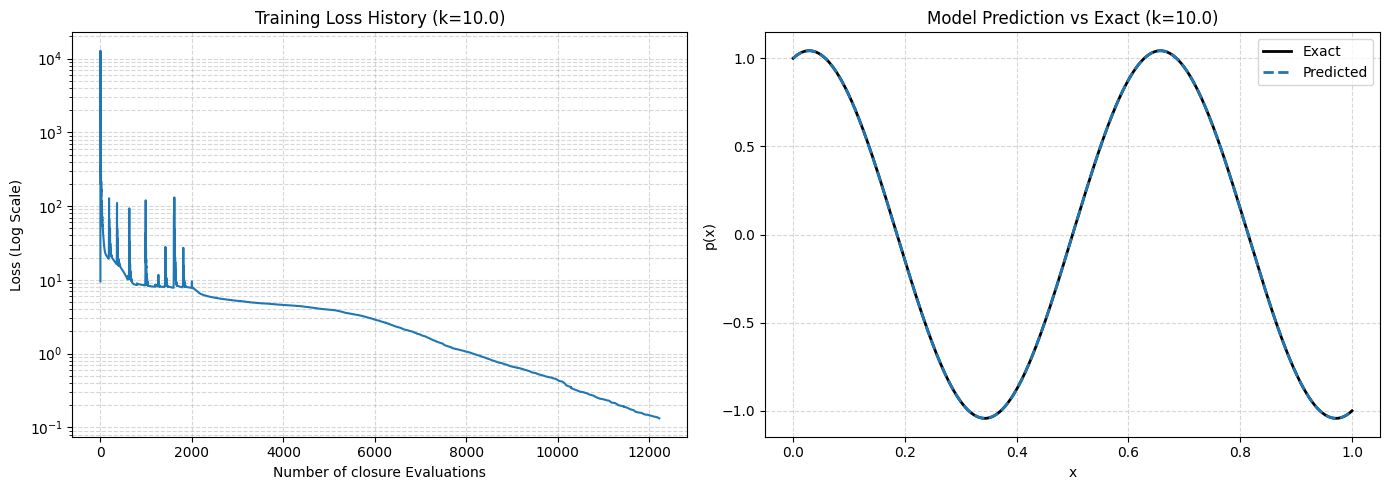

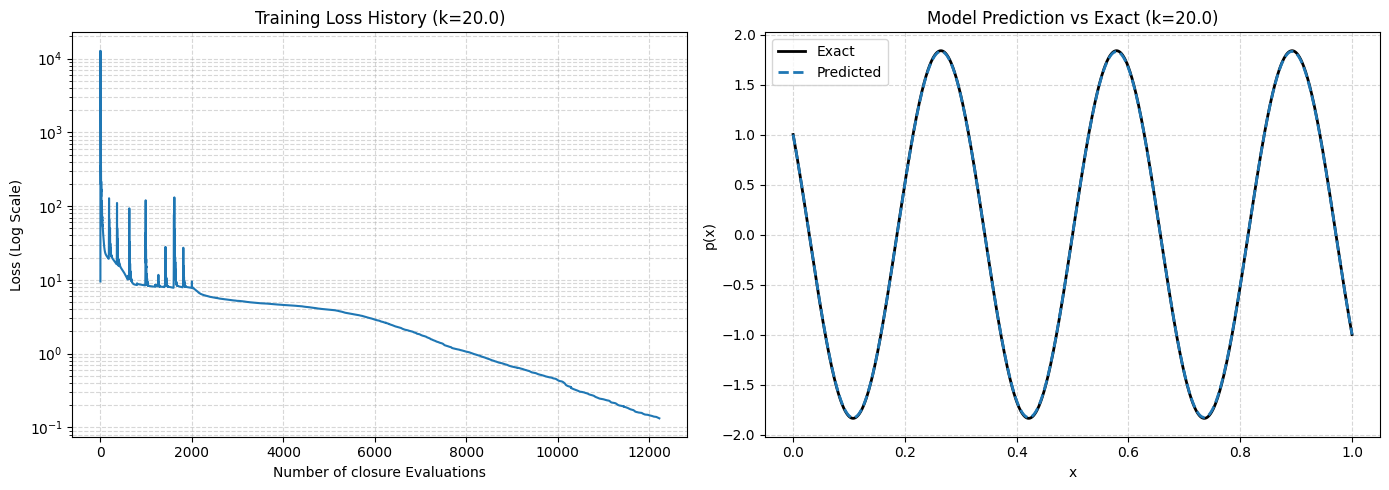

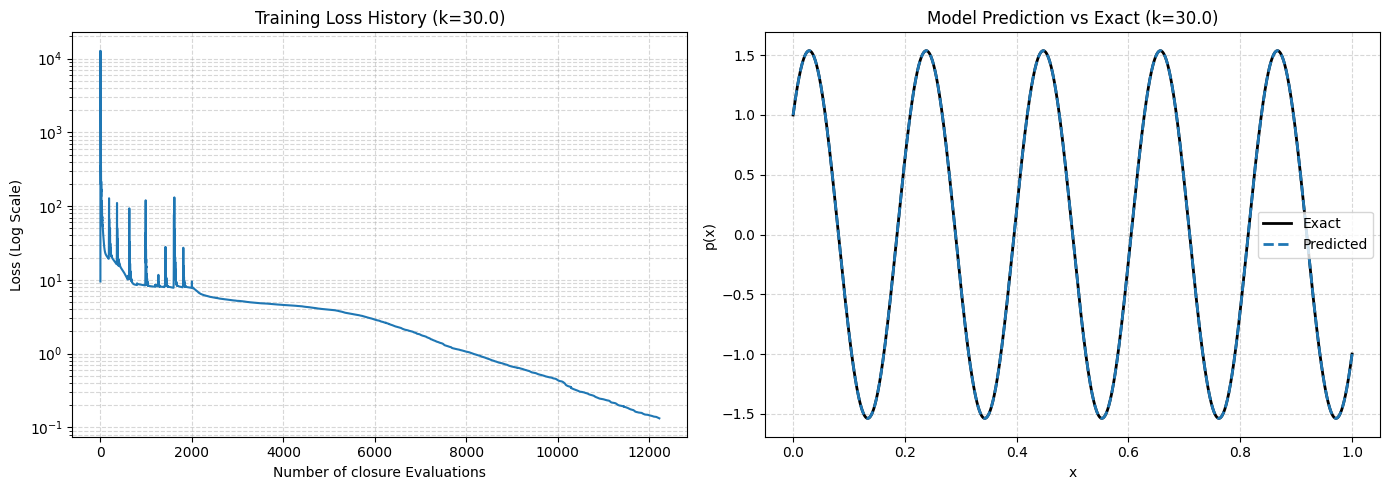

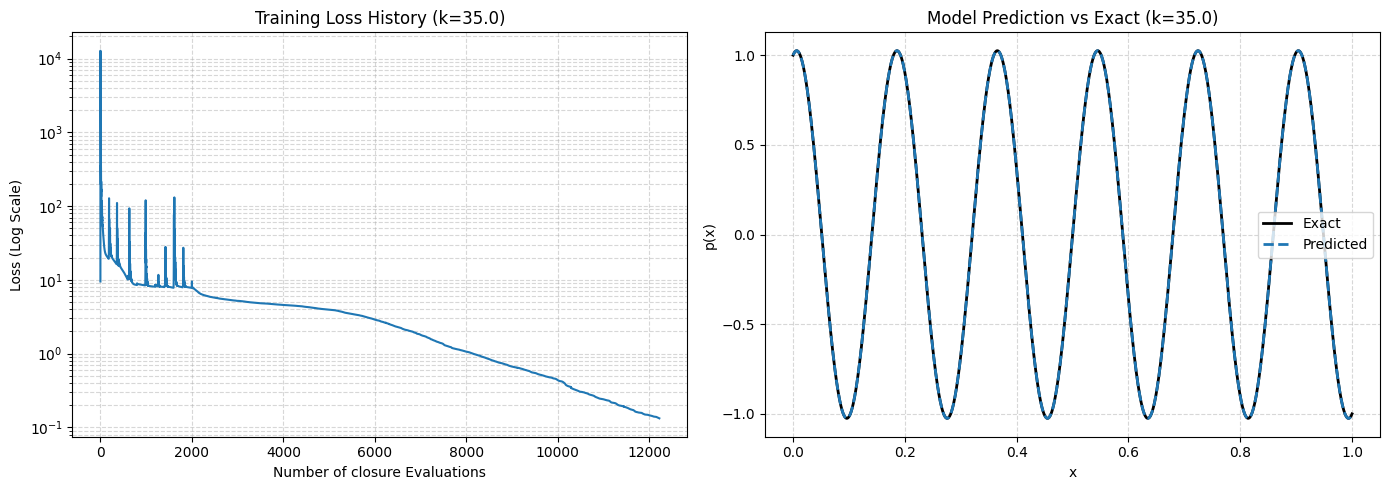

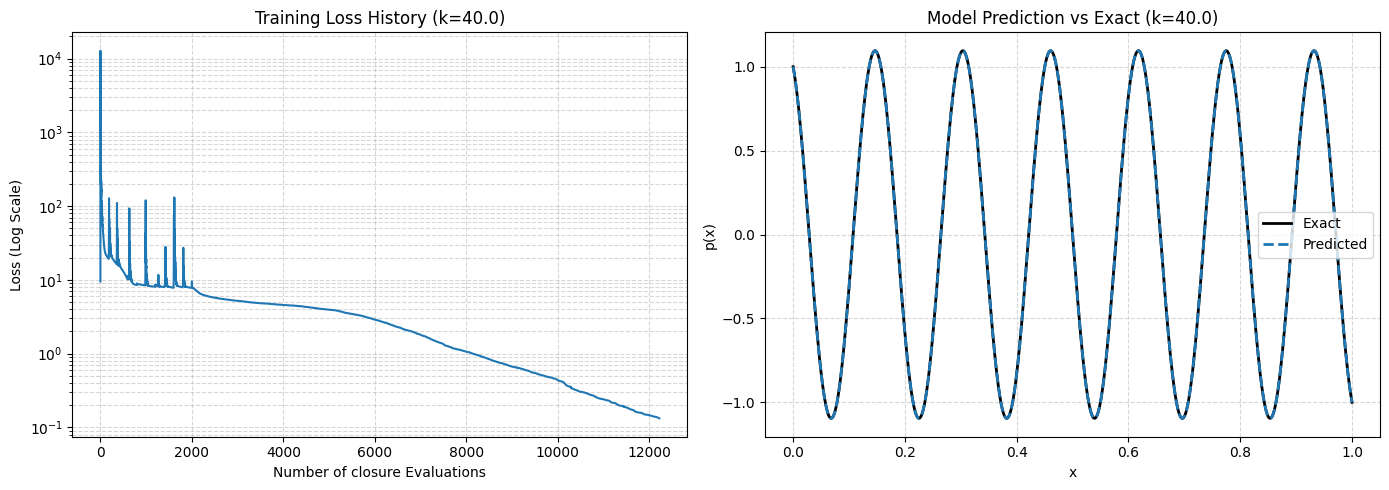

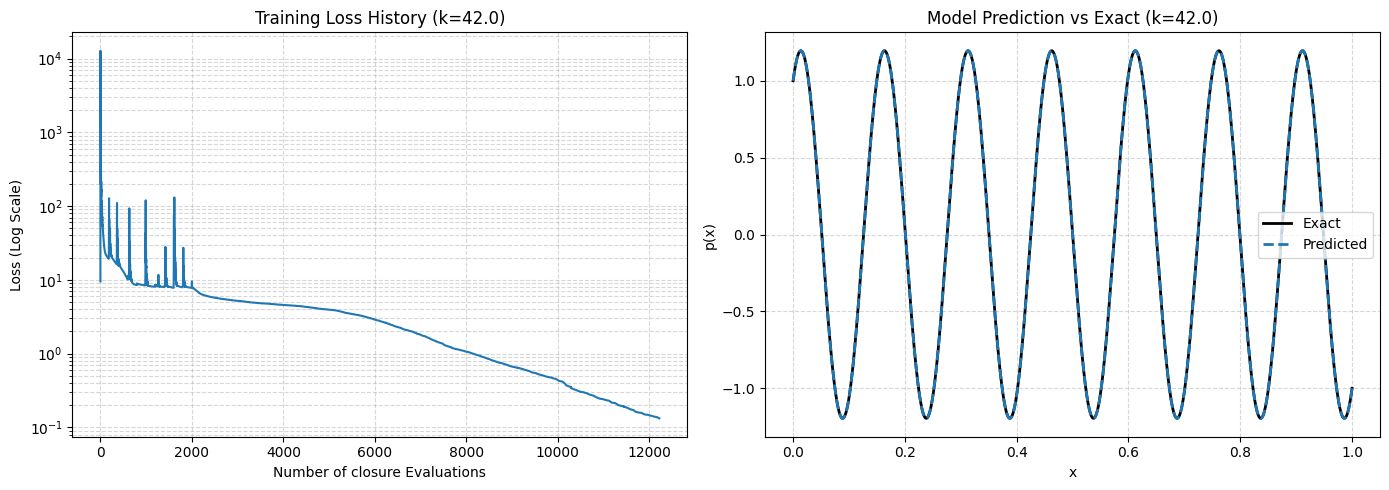

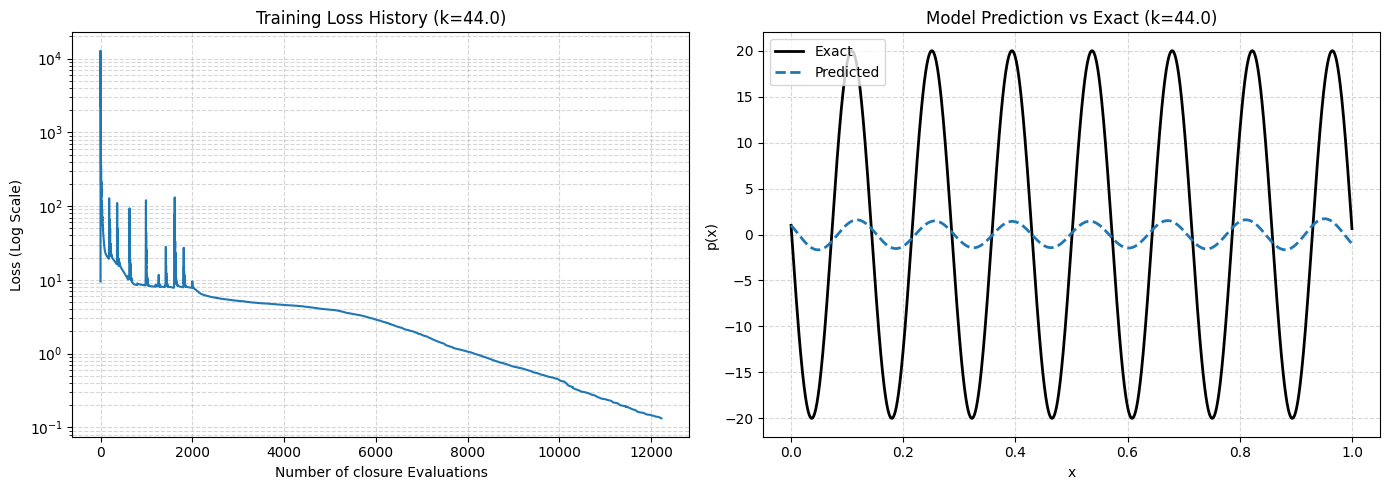

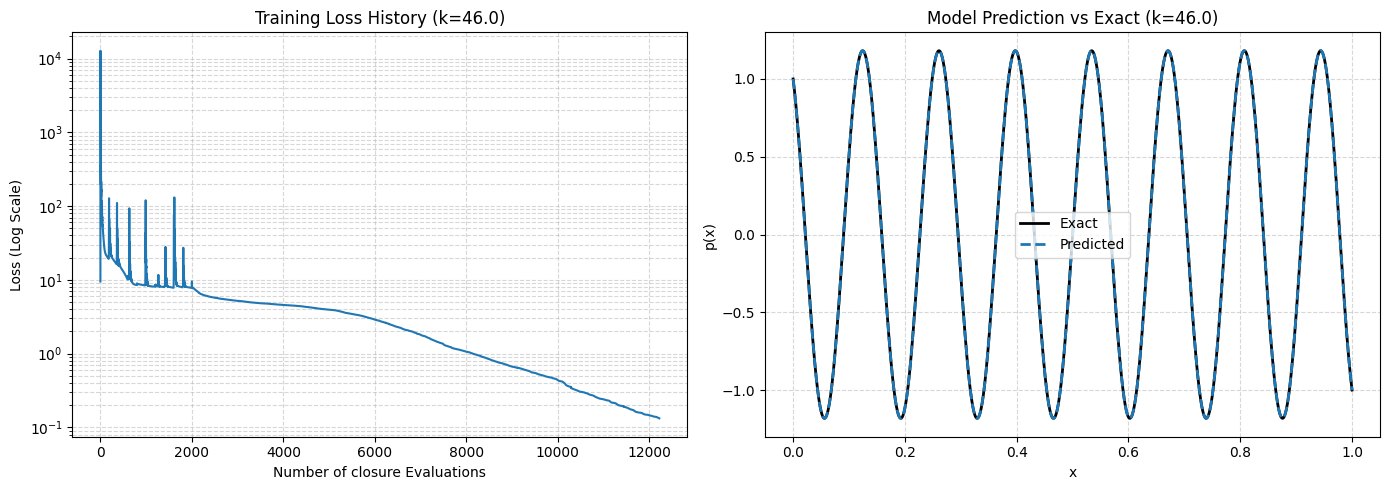

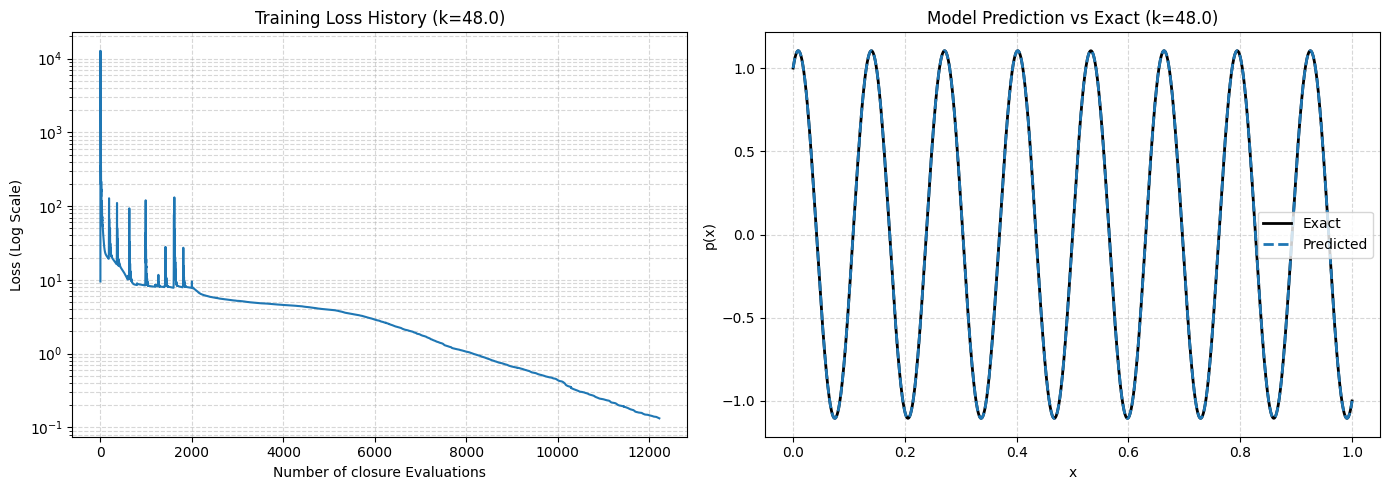

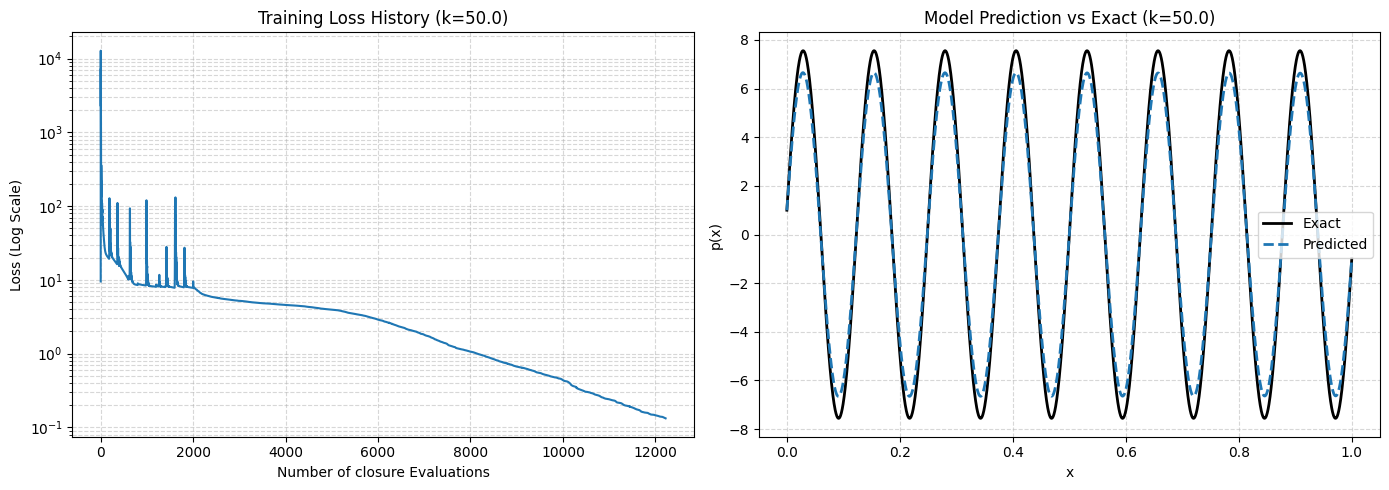

In [18]:
def exact_solution_numpy(x, k):
    denom = np.sin(k)
    denom = denom + 1e-9
    if abs(denom) < 0.1:
        denom = np.sign(denom) * 0.1
        
    c1 = 1.0
    c2 = -(1.0 + np.cos(k)) / denom
    return c1 * np.cos(k * x) + c2 * np.sin(k * x)

i = 0
for k in k_set: 
    with torch.no_grad():
        x_plot = torch.linspace(0, 1, 2000, device=device).view(-1, 1)
        pred_eval = models[i](x_plot).cpu().numpy().flatten()
        
        x_eval = x_plot.cpu().numpy().flatten()
        exact_eval = exact_solution_numpy(x_eval, k)
        i += 1

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(loss_history)
    axs[0].set_yscale("log")
    axs[0].set_xlabel("Number of closure Evaluations")
    axs[0].set_ylabel("Loss (Log Scale)")
    axs[0].set_title(f"Training Loss History (k={k})")
    axs[0].grid(True, which="both", linestyle="--", alpha=0.5)

    axs[1].plot(x_eval, exact_eval, 'k-', linewidth=2, label="Exact")
    axs[1].plot(x_eval, pred_eval, '--', linewidth=2, label="Predicted")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("p(x)")
    axs[1].set_title(f"Model Prediction vs Exact (k={k})")
    axs[1].grid(True, linestyle="--", alpha=0.5)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

In [19]:
def torch_exact_solution ( x, k ):
    c1 = 1.0
    c2 = - ( 1.0 + np.cos ( k ) ) / np.sin ( k )
    return c1 * torch.cos ( k * x ) + c2 * torch.sin ( k * x )

N_eval = 5000
x_eval = torch.linspace ( 0, 1, N_eval, device = device ).view ( -1, 1 )

for i, k in enumerate ( k_set ):
    current_model = models[i]
    current_model.eval()
    
    with torch.no_grad():
        p_pred = current_model ( x_eval )
        p_true = torch_exact_solution ( x_eval, k )
        
        relative_l2_error =  ( torch.norm ( p_true - p_pred, p = 2 ) / torch.norm ( p_true, p = 2 ) ).item()
        
    print(f"k = {k} - Relative L2 Error: {relative_l2_error}")

k = 10.0 - Relative L2 Error: 0.00027253965201393327
k = 20.0 - Relative L2 Error: 0.0043385274704408365
k = 30.0 - Relative L2 Error: 3.460862295891161e-05
k = 35.0 - Relative L2 Error: 0.00020623097971879015
k = 40.0 - Relative L2 Error: 0.0003079815775988676
k = 42.0 - Relative L2 Error: 0.0003168767828758827
k = 44.0 - Relative L2 Error: 0.9875202484331294
k = 46.0 - Relative L2 Error: 5.213840488149476e-05
k = 48.0 - Relative L2 Error: 0.00023681431481172184
k = 50.0 - Relative L2 Error: 0.12059866849278265
